In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv("data/ED_triage.csv")
data

,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0,0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,...,NaN,NaN,86.0,18.0,NaN,96.0,A,3,0,0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
3,13960101011,Male,77,2017,3,21,2,2,6,R53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
4,13960101012,Male,39,2017,3,21,2,2,6,T79.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143577,14001229114,Female,55,2022,3,20,0,23,3,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
143578,14001229115,Female,60,2022,3,20,0,23,6,T18.9,...,NaN,NaN,NaN,NaN,NaN,NaN,A,4,1,0
143579,14001229117,Female,70,2022,3,20,0,23,6,R55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
143580,14001229118,Male,67,2022,3,20,0,23,6,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0


In [3]:
data.head()

,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0,0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,...,NaN,NaN,86.0,18.0,NaN,96.0,A,3,0,0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
3,13960101011,Male,77,2017,3,21,2,2,6,R53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
4,13960101012,Male,39,2017,3,21,2,2,6,T79.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,0


In [4]:
data.describe()

,triage_code,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,explainer_id,NeedFastExecute,...,Source,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,TriageGrade,operational_patient,ref_specialist
count,1.435820e+05,143582.000000,143582.000000,143582.000000,143582.000000,143582.000000,143582.000000,143582.000000,34255.000000,143582.000000,...,56033.000000,24661.000000,24960.000000,35222.000000,33439.000000,139.000000,37659.000000,143582.000000,143582.000000,143582.000000
mean,1.397956e+10,47.625663,2019.094441,6.474078,15.750742,3.020971,13.452557,3.459584,2.820464,1.927240,...,1.676976,114.323101,72.145673,84.055931,16.081043,37.294964,95.227011,2.415547,0.171554,0.006456
std,1.413142e+07,22.244463,1.473353,3.319114,8.804209,2.006296,6.858802,2.287246,0.676229,0.261506,...,0.467979,10.735823,6.903908,10.304655,1.944397,0.716809,2.390544,0.796884,0.376993,0.080091
min,1.396010e+10,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,37.000000,10.000000,47.000000,1.000000,35.000000,80.000000,1.000000,0.000000,0.000000
25%,1.397023e+10,30.000000,2018.000000,4.000000,8.000000,1.000000,9.000000,2.000000,2.000000,2.000000,...,1.000000,110.000000,70.000000,77.000000,15.000000,37.000000,94.000000,2.000000,0.000000,0.000000
50%,1.398042e+10,47.000000,2019.000000,7.000000,16.000000,3.000000,14.000000,3.000000,3.000000,2.000000,...,2.000000,110.000000,70.000000,84.000000,16.000000,37.000000,96.000000,2.000000,0.000000,0.000000
75%,1.399063e+10,65.000000,2020.000000,9.000000,23.000000,5.000000,19.000000,6.000000,3.000000,2.000000,...,2.000000,120.000000,75.000000,88.000000,17.000000,37.500000,97.000000,3.000000,0.000000,0.000000
max,1.400123e+10,116.000000,2022.000000,12.000000,31.000000,6.000000,23.000000,6.000000,14.000000,2.000000,...,2.000000,230.000000,170.000000,167.000000,47.000000,40.000000,100.000000,5.000000,1.000000,1.000000


## Duplicados

In [5]:
dat= data.drop_duplicates()

In [6]:
dat

,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0,0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,...,NaN,NaN,86.0,18.0,NaN,96.0,A,3,0,0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
3,13960101011,Male,77,2017,3,21,2,2,6,R53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
4,13960101012,Male,39,2017,3,21,2,2,6,T79.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143577,14001229114,Female,55,2022,3,20,0,23,3,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
143578,14001229115,Female,60,2022,3,20,0,23,6,T18.9,...,NaN,NaN,NaN,NaN,NaN,NaN,A,4,1,0
143579,14001229117,Female,70,2022,3,20,0,23,6,R55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
143580,14001229118,Male,67,2022,3,20,0,23,6,K92.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0


In [7]:
print( f' Valores totalmente duplicatos: {143408-143582}')

 Valores totalmente duplicatos: -174


In [8]:
ids = dat["triage_code"]
dat[ids.isin(ids[ids.duplicated()])].sort_values("triage_code")

,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
34402,13970207024,Male,26,2018,4,27,5,3,3,T07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
34403,13970207024,Male,26,2018,4,27,5,4,3,T07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
34840,13970213015,Male,50,2018,5,3,4,1,5,R40.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
34844,13970213015,Male,50,2018,5,3,4,2,5,R40.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
35307,13970219024,Male,60,2018,5,9,3,4,6,T50.901A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125009,14000425076,Female,74,2021,7,16,5,17,0,R10.84,...,120.0,70.0,87.0,18.0,NaN,94.0,A,3,0,0
131898,14000721013,Male,50,2021,10,13,3,9,6,T79.9,...,123.0,85.0,100.0,20.0,NaN,95.0,A,3,0,0
131933,14000721013,Male,50,2021,10,13,3,15,6,T79.9,...,123.0,85.0,100.0,20.0,NaN,95.0,A,3,0,0
138963,14001029028,Female,15,2022,1,19,3,11,5,R99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0


In [9]:
# fazer uma tabela com o nome do triage_code e a outra coluna seja as colunas com valores diferentes -> perceber se a duplicação faz sentido

In [10]:
# 1. Filtramos apenas as colunas que possuem valores diferentes para o mesmo triage_code
def get_diff_info(group):
    diffs = {}
    # Iteramos pelas colunas (exceto a de agrupamento)
    for col in group.columns:
        unique_vals = group[col].unique()
        if len(unique_vals) > 1:
            # Armazenamos o nome da coluna e os valores distintos encontrados
            diffs[col] = list(unique_vals)

    # Retornamos uma série com as colunas divergentes e os valores
    return pd.Series({
        'colunas_divergentes': list(diffs.keys()),
        'valores_distintos': diffs
    })

In [11]:
# 2. Aplicamos a lógica ao seu dataframe de duplicados
#df_audit = dat.groupby('triage_code').apply(get_diff_info)

In [12]:
# 3. Limpamos o resultado para focar apenas onde realmente há divergência
df_audit = df_audit[df_audit['colunas_divergentes'].map(len) > 0]

NameError: name 'df_audit' is not defined

In [13]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_audit

NameError: name 'df_audit' is not defined

In [14]:
df_audit.shape

NameError: name 'df_audit' is not defined

Temos 60 linhas em que o unico valor diferente é a hora de admissão -> 'admission_hour', assim podemos eliminar essas linhas para os modelos que usam apenas os parâmetros ChiefComplaint e  Triage_Grade; para os modelos que ultilizam vários parametros não eliminamos.

## Nulos

In [16]:
missing_values = data.isnull().sum()
print("Missing Values:")
print(missing_values)


Missing Values:
triage_code                  0
gender                       0
age                          0
admission_year               0
admission_month              0
admission_day                0
admission_weekday            0
admission_hour               0
kindref                      0
ChiefComplaint               0
explainer_id            109327
NeedFastExecute              0
CriticalStatus           10380
StuporStatus             10380
PainGrade                10316
MentalDistress           10380
MaterialDistress         10380
Source                   87549
BlooddpressurSystol     118921
BlooddpressurDiastol    118622
PulseRate               108360
RespiratoryRate         110143
Temperature             143443
O2Saturation            105923
AVPU                     90558
TriageGrade                  0
operational_patient          0
ref_specialist               0
dtype: int64


## Tipos de valores

In [17]:
# Check data types of each column in the DataFrame
data_types = data.dtypes
print("Data Types:")
print(data_types)


Data Types:
triage_code               int64
gender                      str
age                       int64
admission_year            int64
admission_month           int64
admission_day             int64
admission_weekday         int64
admission_hour            int64
kindref                   int64
ChiefComplaint              str
explainer_id            float64
NeedFastExecute           int64
CriticalStatus          float64
StuporStatus            float64
PainGrade               float64
MentalDistress          float64
MaterialDistress        float64
Source                  float64
BlooddpressurSystol     float64
BlooddpressurDiastol    float64
PulseRate               float64
RespiratoryRate         float64
Temperature             float64
O2Saturation            float64
AVPU                        str
TriageGrade               int64
operational_patient       int64
ref_specialist            int64
dtype: object


## O Data faz sentido?
- qual é a idade máxima e minima? as idades superam os 100 anos?
- os anos de admissão estão dentro do intervalo?
- o dia de admissão é verdadeiro conforme o mês e o ano?
- existem meses marcados com 0 ou superior a 12?
- o dia da semana é verdadeiro conforme o dia, mes e ano?
- as horas de admissão estão entre 0 e 24?
- o chiefcomplaint é verdadeiro?
- explainer_id
- CriticalStatus
- StuporStatus,
- PainGrade,
- MentalDistress,
- MaterialDistress,
- Source,
- BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation estão dentro dos valores normais ou absordos?
- AVPU,
- TriageGrade,
- operational_patient,
- ref_specialist

--- RESUMO DE QUALIDADE ---
[!] Idades Inválidas: 3 casos detetados.
[!] Erros de Mês: 0
[!] Erros de Hora: 0
[!] Saturação O2 > 100%: 0
[!] Pressão Sistólica <= Diastólica: 31
 ---- Visualização da distribuição de erros ----


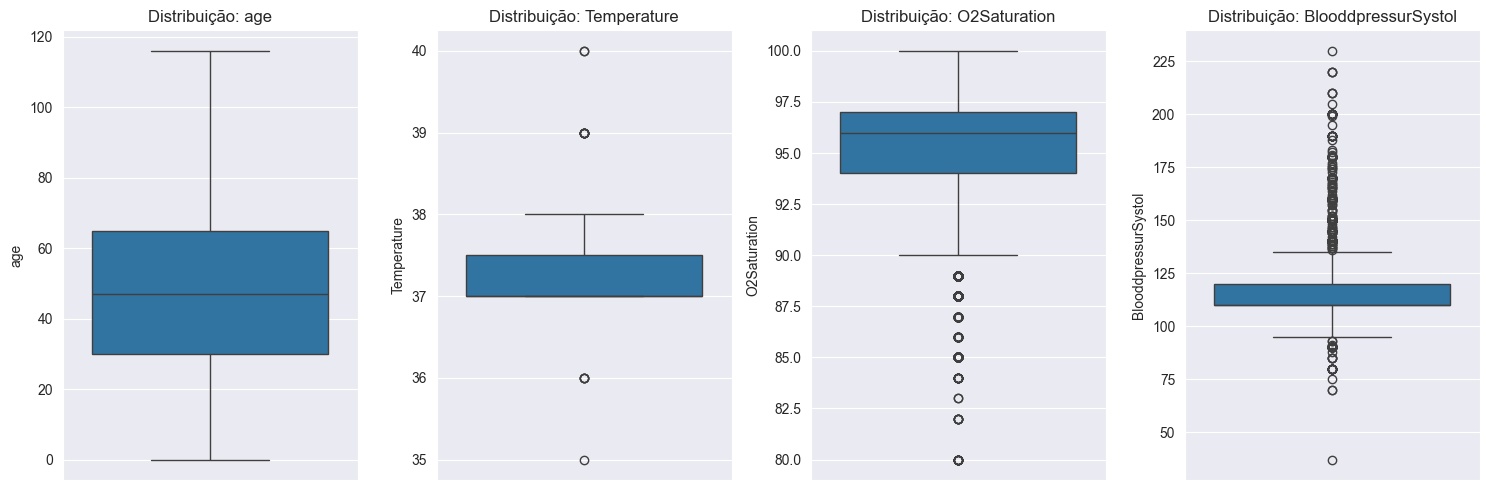

Quantos erros tem cada triage_code? 
 triage_code
13960508105    1
13970412128    1
13970624101    1
13970624110    1
13970804128    1
13970807104    1
13970817151    1
13970923147    1
13971010047    1
13971020012    1
13971027019    1
13971212018    1
13980101080    1
13980202128    1
13980227126    1
13980325118    1
13980606085    1
13980606155    1
13980719035    1
13980723137    1
13980821034    1
13980822101    1
13981020069    1
13981108017    1
13981110040    1
13990107059    1
13990122039    1
13990328091    1
13990405124    1
13990412074    1
13990421065    1
14000424124    1
14001021070    1
14001219088    1
dtype: int64
Quantos erros existem por coluna? 
 error_type
Idade inválida              3
Sistólica <= Diastólica    31
dtype: int64


In [30]:
def error_in_data(df):
    error_details = []   # só dicionários → DataFrame
    error_summary = []   # só strings → print
    def register_error(df_err, error_type, df):
        for idx in df_err.index:
            error_details.append({
                'linha': idx,
                'error_type': error_type,
                'triage_code': int(df.loc[idx, 'triage_code'])
            })


    # --- Verificação de Idade ---
    age_err = df[(df['age'] < 0) | (df['age'] > 110)]
    error_summary.append(f"Idades Inválidas: {len(age_err)} casos detetados.")
    register_error(age_err, 'Idade inválida', df)

    # --- Verificação de Tempo ---
    month_err = df[(df['admission_month'] < 1) | (df['admission_month'] > 12)]
    hour_err = df[(df['admission_hour'] < 0) | (df['admission_hour'] > 23)]
    error_summary.append(f"Erros de Mês: {len(month_err)}")
    error_summary.append(f"Erros de Hora: {len(hour_err)}")
    register_error(month_err, 'Mês inválido',df)
    register_error(hour_err, 'Hora inválida',df)


    # --- Lógica de Sinais Vitais (Valores Absurdos) ---
    temp_err = df[(df['Temperature'] < 30) | (df['Temperature'] > 45)]
    o2_err = df[(df['O2Saturation'] > 100) | (df['O2Saturation'] < 30)]
    register_error(temp_err, 'Temperatura absurda',df)
    register_error(o2_err, 'Saturação O2 inválida',df)

    # Sistólica deve ser maior que Diastólica
    bp_logic_err = df[df['BlooddpressurSystol'] <= df['BlooddpressurDiastol']]
    register_error(bp_logic_err, 'Sistólica <= Diastólica',df)

    error_summary.append(f"Saturação O2 > 100%: {len(df[df['O2Saturation'] > 100])}")
    error_summary.append(f"Pressão Sistólica <= Diastólica: {len(bp_logic_err)}")
    error_df = pd.DataFrame(error_details)

    # Exibir resumo
    print("--- RESUMO DE QUALIDADE ---")
    for e in error_summary:
        print(f"[!] {e}")

    return error_df
# 2. Visualização de Outliers
def plot_vital_signs(df):
    cols_to_plot = ['age', 'Temperature', 'O2Saturation', 'BlooddpressurSystol']
    plt.figure(figsize=(15, 5))

    for i, col in enumerate(cols_to_plot, 1):
        plt.subplot(1, 4, i)
        sns.boxplot(y=df[col])
        plt.title(f'Distribuição: {col}')

    plt.tight_layout()
    plt.show()

# Executar
error_df =error_in_data(data)

print(' ---- Visualização da distribuição de erros ----')
plot_vital_signs(data)

# Ver erros por triage_code
print(f'Quantos erros tem cada triage_code? \n {error_df.groupby('triage_code').size()}')

# Ver erros de um tipo específico
print(f'Quantos erros existem por coluna? \n {error_df.groupby('error_type').size()}')
